In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Set font size and style in matplotlib
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

# Color palette - base and extended use same colors, different line styles
colors = ['#8E8E8E' ,'#C959C5', '#4FC452']

## Setup Extended Model

In [2]:
# Reload module to get latest changes
import importlib
import sys
if 'multi_nutrient_model_ext' in sys.modules:
    importlib.reload(sys.modules['multi_nutrient_model_ext'])

from multi_nutrient_model_ext import (
    ref_parameters as ref_parameters_ext,
    insulin_clamp_dynamic as insulin_clamp_dynamic_ext,
    TAU_INS as TAU_INS_ext,
    AMINO_ACIDS,
)

# Extended model parameters
K_i_ketogenesis = 0.2
R_fatty_acids = 0.008
p_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)

# Get insulin baseline
from multi_nutrient_model_ext import steady_state as steady_state_ext
x0_ext = steady_state_ext(p_ext)
I0_ext = x0_ext[4]

# Insulin levels
vI_low_ext = I0_ext / TAU_INS_ext  # Double basal fasted insulin levels
vI_high_ext = I0_ext / TAU_INS_ext * 3  # Three times low dose

# ATP scaling for extended model (100% - no scaling factor)
PO2 = 5.0
vO2 = 2000
vATP_ext = PO2 * vO2  # No scaling factor for extended model
vE_ext = vATP_ext

# Infusion rates for extended model
sK_ext = 14/27
R_3HB_ext = 120/vE_ext * sK_ext

sL_ext = 200/150
R_lactate_ext = 130/vE_ext * sL_ext

# GIR scaling for extended model
sGIR_ext = vE_ext * 180 * 1e-3

## Setup Base Model

In [3]:
# Import base model
import sys
sys.path.insert(0, '../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    insulin_clamp_dynamic as insulin_clamp_dynamic_base,
    TAU_INS as TAU_INS_base,
    I0 as I0_base,
)

# Base model parameters
p_base = ref_parameters_base(K_i_ketogenesis=K_i_ketogenesis)

# Insulin levels
vI_low_base = I0_base / TAU_INS_base
vI_high_base = I0_base / TAU_INS_base * 3

# ATP scaling for base model (80% scaling factor)
vATP_base = PO2 * vO2 * 0.8  # 0.8 scaling factor for base model
vE_base = vATP_base

# Infusion rates for base model
sK_base = 14/27
R_3HB_base = 120/vE_base * sK_base

sL_base = 200/150
R_lactate_base = 130/vE_base * sL_base

# GIR scaling for base model
sGIR_base = vE_base * 180 * 1e-3

## Low Dose Insulin Clamp (1.25 mU)

Simulate saline, insulin only, and insulin + perturbation conditions.

In [4]:
# Simulation time
time = np.linspace(0, 120, 100)

# =============================================================================
# Extended Model - Low Dose
# =============================================================================

# Saline
x_saline_ext, GIR_saline_ext = insulin_clamp_dynamic_ext(0, time, p=p_ext)

# Insulin only
x_insulin_low_ext, GIR_insulin_low_ext = insulin_clamp_dynamic_ext(vI_low_ext, time, p=p_ext)

# Insulin + Intralipid
x_insulin_low_intralipid_ext, GIR_insulin_low_intralipid_ext = insulin_clamp_dynamic_ext(
    vI_low_ext, time, p=p_ext, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_low_3HB_ext, GIR_insulin_low_3HB_ext = insulin_clamp_dynamic_ext(
    vI_low_ext, time, p=p_ext, R_3HB=R_3HB_ext)

# Insulin + Lactate
x_insulin_low_lactate_ext, GIR_insulin_low_lactate_ext = insulin_clamp_dynamic_ext(
    vI_low_ext, time, p=p_ext, R_lactate=R_lactate_ext)

# =============================================================================
# Base Model - Low Dose
# =============================================================================

# Saline
x_saline_base, GIR_saline_base = insulin_clamp_dynamic_base(0, time, 1.0, p=p_base)

# Insulin only
x_insulin_low_base, GIR_insulin_low_base = insulin_clamp_dynamic_base(vI_low_base, time, 1.0, p=p_base)

# Insulin + Intralipid
x_insulin_low_intralipid_base, GIR_insulin_low_intralipid_base = insulin_clamp_dynamic_base(
    vI_low_base, time, 1.0, p=p_base, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_low_3HB_base, GIR_insulin_low_3HB_base = insulin_clamp_dynamic_base(
    vI_low_base, time, 1.0, p=p_base, R_3HB=R_3HB_base)

# Insulin + Lactate
x_insulin_low_lactate_base, GIR_insulin_low_lactate_base = insulin_clamp_dynamic_base(
    vI_low_base, time, 1.0, p=p_base, R_lactate=R_lactate_base)

# =============================================================================
# Scale metabolites to physiological units
# =============================================================================

# Extended model
for df in [x_saline_ext, x_insulin_low_ext, x_insulin_low_intralipid_ext, 
           x_insulin_low_3HB_ext, x_insulin_low_lactate_ext]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Base model
for df in [x_saline_base, x_insulin_low_base, x_insulin_low_intralipid_base,
           x_insulin_low_3HB_base, x_insulin_low_lactate_base]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Scale GIR with respective vE for each model
for df in [GIR_saline_ext, GIR_insulin_low_ext, GIR_insulin_low_intralipid_ext,
           GIR_insulin_low_3HB_ext, GIR_insulin_low_lactate_ext]:
    df['GIR'] = df['GIR'] * sGIR_ext

for df in [GIR_saline_base, GIR_insulin_low_base, GIR_insulin_low_intralipid_base,
           GIR_insulin_low_3HB_base, GIR_insulin_low_lactate_base]:
    df['GIR'] = df['GIR'] * sGIR_base

In [5]:
# Compute steady-state values for the lactate extend model
from multi_nutrient_model_ext import change_parameters
p_ext_insulin = change_parameters(p_ext,{'R_lactate':R_lactate_ext})
x0 = steady_state_ext(p_ext, xtol=1e-12)
x0

array([1.10484519, 1.00728828, 1.01733046, 1.06481504, 0.05444643,
       0.05444643, 0.3549807 , 0.3549807 , 0.51475079, 1.03088892,
       1.03088892, 1.03088892, 1.03088892, 0.83692406, 1.03088892,
       1.03088892, 1.03088892, 1.03088892, 1.03088892, 1.03088892,
       1.03088892, 1.03088892, 1.03088892, 1.03088892, 1.03088892,
       1.03088892, 1.03088892])

## Comparison Plots - Low Dose Insulin (1.25 mU)

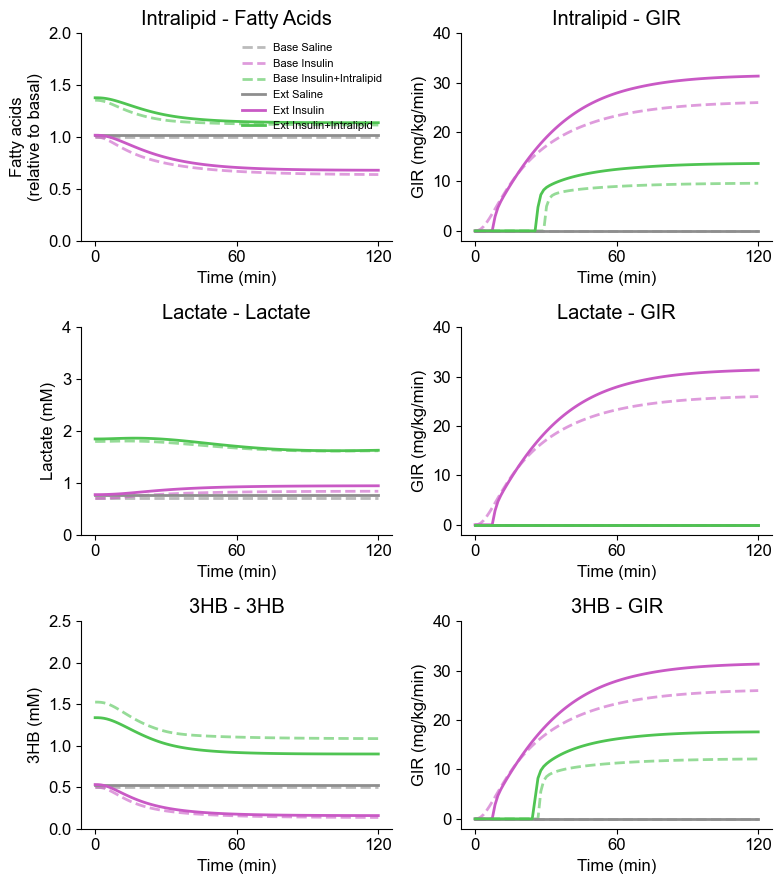

In [6]:
# Create 3x2 grid for low dose comparison
fig, axs = plt.subplots(3, 2, figsize=(8, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Row 1: Intralipid
# Fatty acids
axs[0,0].plot(x_saline_base['time'], x_saline_base['F'], 
              color=colors[0], linestyle='--', linewidth=2, label='Base Saline', alpha=0.6)
axs[0,0].plot(x_insulin_low_base['time'], x_insulin_low_base['F'], 
              color=colors[1], linestyle='--', linewidth=2, label='Base Insulin', alpha=0.6)
axs[0,0].plot(x_insulin_low_intralipid_base['time'], x_insulin_low_intralipid_base['F'], 
              color=colors[2], linestyle='--', linewidth=2, label='Base Insulin+Intralipid', alpha=0.6)
axs[0,0].plot(x_saline_ext['time'], x_saline_ext['F'], 
              color=colors[0], linestyle='-', linewidth=2, label='Ext Saline')
axs[0,0].plot(x_insulin_low_ext['time'], x_insulin_low_ext['F'], 
              color=colors[1], linestyle='-', linewidth=2, label='Ext Insulin')
axs[0,0].plot(x_insulin_low_intralipid_ext['time'], x_insulin_low_intralipid_ext['F'], 
              color=colors[2], linestyle='-', linewidth=2, label='Ext Insulin+Intralipid')
axs[0,0].set_ylabel('Fatty acids\n(relative to basal)')
axs[0,0].set_xlabel('Time (min)')
axs[0,0].set_ylim(0, 2)
axs[0,0].set_title('Intralipid - Fatty Acids')
axs[0,0].legend(frameon=False, fontsize=8, loc='upper right')

# GIR
axs[0,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_low_base['time'], GIR_insulin_low_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_low_intralipid_base['time'], GIR_insulin_low_intralipid_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_low_ext['time'], GIR_insulin_low_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_low_intralipid_ext['time'], GIR_insulin_low_intralipid_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[0,1].set_ylabel('GIR (mg/kg/min)')
axs[0,1].set_xlabel('Time (min)')
axs[0,1].set_ylim(-2, 40)
axs[0,1].set_title('Intralipid - GIR')

# Row 2: Lactate
# Lactate
axs[1,0].plot(x_saline_base['time'], x_saline_base['L'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[1,0].plot(x_insulin_low_base['time'], x_insulin_low_base['L'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[1,0].plot(x_insulin_low_lactate_base['time'], x_insulin_low_lactate_base['L'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[1,0].plot(x_saline_ext['time'], x_saline_ext['L'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[1,0].plot(x_insulin_low_ext['time'], x_insulin_low_ext['L'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[1,0].plot(x_insulin_low_lactate_ext['time'], x_insulin_low_lactate_ext['L'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[1,0].set_ylabel('Lactate (mM)')
axs[1,0].set_xlabel('Time (min)')
axs[1,0].set_ylim(0, 4)
axs[1,0].set_title('Lactate - Lactate')

# GIR
axs[1,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_low_base['time'], GIR_insulin_low_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_low_lactate_base['time'], GIR_insulin_low_lactate_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_low_ext['time'], GIR_insulin_low_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_low_lactate_ext['time'], GIR_insulin_low_lactate_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[1,1].set_ylabel('GIR (mg/kg/min)')
axs[1,1].set_xlabel('Time (min)')
axs[1,1].set_ylim(-2, 40)
axs[1,1].set_title('Lactate - GIR')

# Row 3: 3HB
# 3HB
axs[2,0].plot(x_saline_base['time'], x_saline_base['K'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[2,0].plot(x_insulin_low_base['time'], x_insulin_low_base['K'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[2,0].plot(x_insulin_low_3HB_base['time'], x_insulin_low_3HB_base['K'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[2,0].plot(x_saline_ext['time'], x_saline_ext['K'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[2,0].plot(x_insulin_low_ext['time'], x_insulin_low_ext['K'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[2,0].plot(x_insulin_low_3HB_ext['time'], x_insulin_low_3HB_ext['K'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[2,0].set_ylabel('3HB (mM)')
axs[2,0].set_xlabel('Time (min)')
axs[2,0].set_ylim(0, 2.5)
axs[2,0].set_title('3HB - 3HB')

# GIR
axs[2,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_low_base['time'], GIR_insulin_low_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_low_3HB_base['time'], GIR_insulin_low_3HB_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_low_ext['time'], GIR_insulin_low_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_low_3HB_ext['time'], GIR_insulin_low_3HB_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[2,1].set_ylabel('GIR (mg/kg/min)')
axs[2,1].set_xlabel('Time (min)')
axs[2,1].set_ylim(-2, 40)
axs[2,1].set_title('3HB - GIR')

# Set x-axis ticks
for i in range(3):
    for j in range(2):
        axs[i,j].set_xticks([0, 60, 120])

sns.despine()
plt.tight_layout()
plt.savefig('./output/hyperinsulinemic_clamp_low_dose_comparison.svg', bbox_inches='tight')
plt.show()

## High Dose Insulin Clamp (2.5 mU)

In [7]:
# =============================================================================
# Extended Model - High Dose
# =============================================================================

# Insulin only
x_insulin_high_ext, GIR_insulin_high_ext = insulin_clamp_dynamic_ext(vI_high_ext, time, p=p_ext)

# Insulin + Intralipid
x_insulin_high_intralipid_ext, GIR_insulin_high_intralipid_ext = insulin_clamp_dynamic_ext(
    vI_high_ext, time, p=p_ext, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_high_3HB_ext, GIR_insulin_high_3HB_ext = insulin_clamp_dynamic_ext(
    vI_high_ext, time, p=p_ext, R_3HB=R_3HB_ext)

# Insulin + Lactate
x_insulin_high_lactate_ext, GIR_insulin_high_lactate_ext = insulin_clamp_dynamic_ext(
    vI_high_ext, time, p=p_ext, R_lactate=R_lactate_ext)

# =============================================================================
# Base Model - High Dose
# =============================================================================

# Insulin only
x_insulin_high_base, GIR_insulin_high_base = insulin_clamp_dynamic_base(vI_high_base, time, 1.0, p=p_base)

# Insulin + Intralipid
x_insulin_high_intralipid_base, GIR_insulin_high_intralipid_base = insulin_clamp_dynamic_base(
    vI_high_base, time, 1.0, p=p_base, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_high_3HB_base, GIR_insulin_high_3HB_base = insulin_clamp_dynamic_base(
    vI_high_base, time, 1.0, p=p_base, R_3HB=R_3HB_base)

# Insulin + Lactate
x_insulin_high_lactate_base, GIR_insulin_high_lactate_base = insulin_clamp_dynamic_base(
    vI_high_base, time, 1.0, p=p_base, R_lactate=R_lactate_base)

# =============================================================================
# Scale metabolites to physiological units
# =============================================================================

# Extended model
for df in [x_insulin_high_ext, x_insulin_high_intralipid_ext, 
           x_insulin_high_3HB_ext, x_insulin_high_lactate_ext]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Base model
for df in [x_insulin_high_base, x_insulin_high_intralipid_base,
           x_insulin_high_3HB_base, x_insulin_high_lactate_base]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Scale GIR with respective vE for each model
for df in [GIR_insulin_high_ext, GIR_insulin_high_intralipid_ext,
           GIR_insulin_high_3HB_ext, GIR_insulin_high_lactate_ext]:
    df['GIR'] = df['GIR'] * sGIR_ext

for df in [GIR_insulin_high_base, GIR_insulin_high_intralipid_base,
           GIR_insulin_high_3HB_base, GIR_insulin_high_lactate_base]:
    df['GIR'] = df['GIR'] * sGIR_base

## Comparison Plots - High Dose Insulin (2.5 mU)

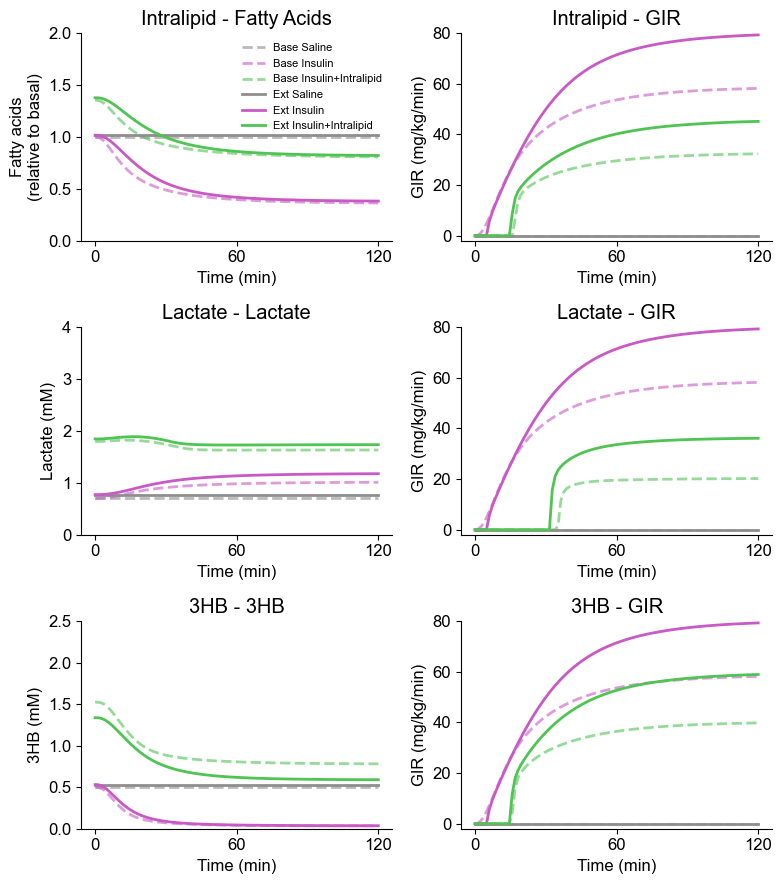

In [8]:
# Create 3x2 grid for high dose comparison
fig, axs = plt.subplots(3, 2, figsize=(8, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Row 1: Intralipid
# Fatty acids
axs[0,0].plot(x_saline_base['time'], x_saline_base['F'], 
              color=colors[0], linestyle='--', linewidth=2, label='Base Saline', alpha=0.6)
axs[0,0].plot(x_insulin_high_base['time'], x_insulin_high_base['F'], 
              color=colors[1], linestyle='--', linewidth=2, label='Base Insulin', alpha=0.6)
axs[0,0].plot(x_insulin_high_intralipid_base['time'], x_insulin_high_intralipid_base['F'], 
              color=colors[2], linestyle='--', linewidth=2, label='Base Insulin+Intralipid', alpha=0.6)
axs[0,0].plot(x_saline_ext['time'], x_saline_ext['F'], 
              color=colors[0], linestyle='-', linewidth=2, label='Ext Saline')
axs[0,0].plot(x_insulin_high_ext['time'], x_insulin_high_ext['F'], 
              color=colors[1], linestyle='-', linewidth=2, label='Ext Insulin')
axs[0,0].plot(x_insulin_high_intralipid_ext['time'], x_insulin_high_intralipid_ext['F'], 
              color=colors[2], linestyle='-', linewidth=2, label='Ext Insulin+Intralipid')
axs[0,0].set_ylabel('Fatty acids\n(relative to basal)')
axs[0,0].set_xlabel('Time (min)')
axs[0,0].set_ylim(0, 2)
axs[0,0].set_title('Intralipid - Fatty Acids')
axs[0,0].legend(frameon=False, fontsize=8, loc='upper right')

# GIR
axs[0,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_high_base['time'], GIR_insulin_high_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_high_intralipid_base['time'], GIR_insulin_high_intralipid_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_high_ext['time'], GIR_insulin_high_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_high_intralipid_ext['time'], GIR_insulin_high_intralipid_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[0,1].set_ylabel('GIR (mg/kg/min)')
axs[0,1].set_xlabel('Time (min)')
axs[0,1].set_ylim(-2, 80)
axs[0,1].set_title('Intralipid - GIR')

# Row 2: Lactate
# Lactate
axs[1,0].plot(x_saline_base['time'], x_saline_base['L'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[1,0].plot(x_insulin_high_base['time'], x_insulin_high_base['L'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[1,0].plot(x_insulin_high_lactate_base['time'], x_insulin_high_lactate_base['L'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[1,0].plot(x_saline_ext['time'], x_saline_ext['L'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[1,0].plot(x_insulin_high_ext['time'], x_insulin_high_ext['L'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[1,0].plot(x_insulin_high_lactate_ext['time'], x_insulin_high_lactate_ext['L'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[1,0].set_ylabel('Lactate (mM)')
axs[1,0].set_xlabel('Time (min)')
axs[1,0].set_ylim(0, 4)
axs[1,0].set_title('Lactate - Lactate')

# GIR
axs[1,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_high_base['time'], GIR_insulin_high_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_high_lactate_base['time'], GIR_insulin_high_lactate_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_high_ext['time'], GIR_insulin_high_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_high_lactate_ext['time'], GIR_insulin_high_lactate_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[1,1].set_ylabel('GIR (mg/kg/min)')
axs[1,1].set_xlabel('Time (min)')
axs[1,1].set_ylim(-2, 80)
axs[1,1].set_title('Lactate - GIR')

# Row 3: 3HB
# 3HB
axs[2,0].plot(x_saline_base['time'], x_saline_base['K'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[2,0].plot(x_insulin_high_base['time'], x_insulin_high_base['K'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[2,0].plot(x_insulin_high_3HB_base['time'], x_insulin_high_3HB_base['K'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[2,0].plot(x_saline_ext['time'], x_saline_ext['K'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[2,0].plot(x_insulin_high_ext['time'], x_insulin_high_ext['K'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[2,0].plot(x_insulin_high_3HB_ext['time'], x_insulin_high_3HB_ext['K'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[2,0].set_ylabel('3HB (mM)')
axs[2,0].set_xlabel('Time (min)')
axs[2,0].set_ylim(0, 2.5)
axs[2,0].set_title('3HB - 3HB')

# GIR
axs[2,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_high_base['time'], GIR_insulin_high_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_high_3HB_base['time'], GIR_insulin_high_3HB_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_high_ext['time'], GIR_insulin_high_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_high_3HB_ext['time'], GIR_insulin_high_3HB_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[2,1].set_ylabel('GIR (mg/kg/min)')
axs[2,1].set_xlabel('Time (min)')
axs[2,1].set_ylim(-2, 80)
axs[2,1].set_title('3HB - GIR')

# Set x-axis ticks
for i in range(3):
    for j in range(2):
        axs[i,j].set_xticks([0, 60, 120])

sns.despine()
plt.tight_layout()
plt.savefig('./output/hyperinsulinemic_clamp_high_dose_comparison.svg', bbox_inches='tight')
plt.show()